# Analiza danych tekstowych, porównanie technik obróbki tekstu w kontekście klasyfikacji

Wykonanie analizy oraz stworzenie modeli klasyfikacji tekstu w kontekście analizy sentymentu na podstawie danych SPAM ([Link do zbioru danych w serwisie Kaggle](https://www.kaggle.com/datasets/team-ai/spam-text-message-classification)). Wykorzystanie różnych technik przetwarzania tekstu oraz porównanie ich skuteczności w klasyfikacji sentymentu.

In [1]:
import pandas as pd

df_train = pd.read_csv("../../data/SPAM_text_2017.csv", encoding="latin-1")

In [2]:
print(f"== DF TRAIN COLUMNS ==")
print(f"train: {df_train.columns.to_list()}\n")
print(f"== DF TRAIN SHAPE ==")
print(f"train: {df_train.shape}\n")

== DF TRAIN COLUMNS ==
train: ['Category', 'Message']

== DF TRAIN SHAPE ==
train: (5572, 2)



Text(0, 0.5, 'Count')

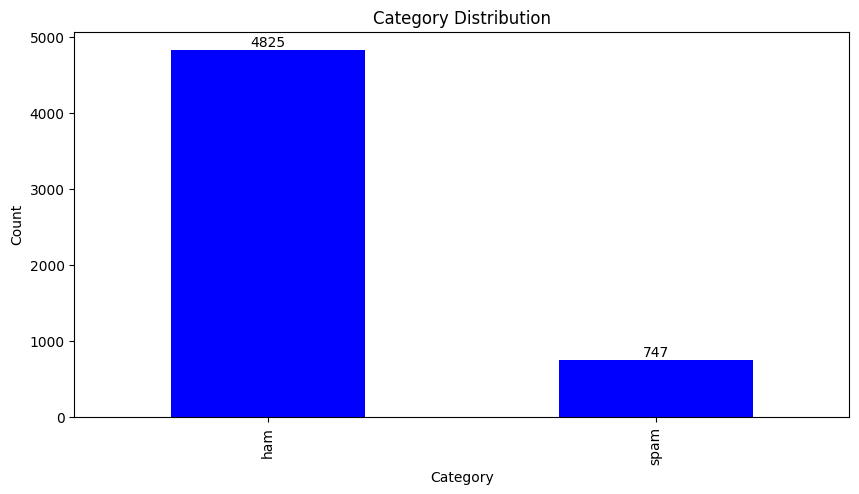

In [3]:
import matplotlib.pyplot as plt

df = df_train
data = df_train['Category'].value_counts()

plt.plot()
data.plot(kind='bar', color='blue', figsize=(10, 5))
for i, v in enumerate(data):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10)
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

W tym zbiorze danych mamy bardzo nierównomierny rozkład cechy `Category`. Początkowo decydujemy się go zostawić, ponieważ może być to naturalne podejście do badanego problemu, tzn. o wiele więcej wiadomości nie będzie spamem. 

## Preprocesowanie danych

In [4]:
lst = df['Message'][:3].tolist()
for l in lst:
    print(f"{l}\n")

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Ok lar... Joking wif u oni...

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's



Możemy zaobserwować, że mogą trafić się wiadomości, które nie zawsze będą pisane poprawnie, a także występować będą nazwy własne jak np. nicki użytkowników czy tym podobne (np. 08452810075over18).

### Sprowadzenie tesktu do małych liter

In [5]:
print(f"== BEFORE LOWER ==\n{df['Message'][:3]}\n")
df['ProcessedMessage'] = df['Message'].str.lower()
print(f"== AFTER LOWER ==\n{df['ProcessedMessage'][:3]}\n")

== BEFORE LOWER ==
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
Name: Message, dtype: object

== AFTER LOWER ==
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
Name: ProcessedMessage, dtype: object



### Usunięcie oznaczeń i linków do stron internetowych

In [6]:
def remove_usernames_and_links(text):
    text = ' '.join([word for word in text.split() if not word.startswith('@')])
    text = ' '.join([word for word in text.split() if not '@' in word])
    text = ' '.join([word for word in text.split() if not word.startswith('http')])
    return text

In [7]:
counter = 0

for i, row in df.iterrows():
    if 'http' in row['ProcessedMessage']:
        print(f"Row {i} contains URL")
        print(f'\t Message: {row["ProcessedMessage"]}')
        counter += 1
        
print(f"== Detected URLs in dataset {counter}/{len(df)} ==\n")

Row 15 contains URL
	 Message: xxxmobilemovieclub: to use your credit, click the wap link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=qjkgighjjgcbl
Row 305 contains URL
	 Message: sms. ac blind date 4u!: rodds1 is 21/m from aberdeen, united kingdom. check him out http://img. sms. ac/w/icmb3cktz8r7!-4 no blind dates send hide
Row 518 contains URL
	 Message: your credits have been topped up for http://www.bubbletext.com your renewal pin is tgxxrz
Row 635 contains URL
	 Message: dear voucher holder, 2 claim this weeks offer, at your pc go to http://www.e-tlp.co.uk/expressoffer ts&cs apply.2 stop texts txt stop to 80062.
Row 833 contains URL
	 Message: dear voucher holder, to claim this weeks offer, at you pc please go to http://www.e-tlp.co.uk/expressoffer ts&cs apply. to stop texts, txt stop to 80062
Row 881 contains URL
	 Message: reminder: you have not downloaded the content you have already paid for. goto http://doit. mymoby. tv/ to collect your conten

In [8]:
print(f"== BEFORE NICKS AND LINKS ==\n{df['ProcessedMessage'][13:17]}\n")
df['ProcessedMessage'] = df['ProcessedMessage'].apply(remove_usernames_and_links)
print(f"== AFTER NICKS AND LINKS ==\n{df['ProcessedMessage'][13:17]}\n")

== BEFORE NICKS AND LINKS ==
13    i've been searching for the right words to tha...
14                  i have a date on sunday with will!!
15    xxxmobilemovieclub: to use your credit, click ...
16                           oh k...i'm watching here:)
Name: ProcessedMessage, dtype: object

== AFTER NICKS AND LINKS ==
13    i've been searching for the right words to tha...
14                  i have a date on sunday with will!!
15    xxxmobilemovieclub: to use your credit, click ...
16                           oh k...i'm watching here:)
Name: ProcessedMessage, dtype: object



### Usunięcie słów stopu

In [9]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
from nltk.corpus import stopwords
stop_words = list(stopwords.words('english'))

In [11]:
print(f"== ENGLISH STOPWORDS ==\n{len(stop_words)}\n{stop_words[:10]}\n")

== ENGLISH STOPWORDS ==
198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']



In [12]:
print(f"== BEFORE STOPWORDS ==\n{df['ProcessedMessage'][:3]}\n")
df['ProcessedMessage'] = df['ProcessedMessage'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))
print(f"== AFTER STOPWORDS ==\n{df['ProcessedMessage'][:3]}\n")

== BEFORE STOPWORDS ==
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
Name: ProcessedMessage, dtype: object

== AFTER STOPWORDS ==
0    go jurong point, crazy.. available bugis n gre...
1                        ok lar... joking wif u oni...
2    free entry 2 wkly comp win fa cup final tkts 2...
Name: ProcessedMessage, dtype: object



### Usunięcie znaków interpunkcyjnych i cyfr

In [13]:
import re

def remove_numbers(text):
    result = re.sub(r'\d+', '', text)
    return result

def remove_punctuation(text):
    result = re.sub(r'[^\w\s]', '', text)
    return result

In [14]:
print(f"== BEFORE NUMBERS AND PUNCTUATION ==\n{df['ProcessedMessage'][:3]}\n")
df['ProcessedMessage'] = df['ProcessedMessage'].apply(remove_numbers)
df['ProcessedMessage'] = df['ProcessedMessage'].apply(remove_punctuation)
print(f"== AFTER NUMBERS AND PUNCTUATION ==\n{df['ProcessedMessage'][:3]}\n")

== BEFORE NUMBERS AND PUNCTUATION ==
0    go jurong point, crazy.. available bugis n gre...
1                        ok lar... joking wif u oni...
2    free entry 2 wkly comp win fa cup final tkts 2...
Name: ProcessedMessage, dtype: object

== AFTER NUMBERS AND PUNCTUATION ==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry  wkly comp win fa cup final tkts st...
Name: ProcessedMessage, dtype: object



### Weryfikacja zbioru po przeczyszczeniu

In [15]:
print(f"Total number of rows in the dataset: {df.shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['ProcessedMessage'] == ''].shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['ProcessedMessage'] == ' '].shape[0]}")
print(f"Total number of rows with empty tweets: {df[df['ProcessedMessage'] == None].shape[0]}")

Total number of rows in the dataset: 5572
Total number of rows with empty tweets: 3
Total number of rows with empty tweets: 1
Total number of rows with empty tweets: 0


Widzimy łącznie 4 rekordy, które podczas czyszczenia zbioru danych ze słów stopu, znaków interpunkcyjnych i linków zostatły puste

In [16]:
idx = df[df['ProcessedMessage'] == ''].index
idx2 = df[df['ProcessedMessage'] == ' '].index
    
print(f"{df['Category'].iloc[idx].value_counts()}")    
print(f"{df['Category'].iloc[idx2].value_counts()}")    

Category
ham    3
Name: count, dtype: int64
Category
ham    1
Name: count, dtype: int64


Rekordy te mają kategorię tylko `ham` stąd dodanie pustych rekordów zaklasyfikowanych jako `ham` może wprowadzać szum.

In [17]:
print(f"== BEFORE DELETE RECORDS ==\t{df.shape[0]}")
df = df[df['ProcessedMessage'] != '']
df = df[df['ProcessedMessage'] != ' ']
print(f"== AFTER DELETE RECORDS ==\t{df.shape[0]}")

== BEFORE DELETE RECORDS ==	5572
== AFTER DELETE RECORDS ==	5568


### TextBlob - Próba wykorzystania narzędzia służącego do poprawienia błędów w słowach

In [18]:
!pip install textblob


[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from textblob import TextBlob

Podejście może poprawić zdania a także zwiększyć ich sens. Przeprowadzimy jeszcze test statystyczny zmian w rekordach. 

In [21]:
df['ProcessedMessageTextBlob'] = df['ProcessedMessage'].apply(lambda x: str(TextBlob(x).correct()))

In [22]:
df['num_changes'] = df.apply(lambda row: sum(1 for o, c in zip(row['ProcessedMessage'].split(), row['ProcessedMessageTextBlob'].split()) if o != c), axis=1)
df['total_words'] = df['ProcessedMessage'].apply(lambda x: len(x.split()))
df['change_ratio'] = df['num_changes'] / df['total_words']

total_words = df['total_words'].sum()
total_changes = df['num_changes'].sum()
percentage_change = (total_changes / total_words) * 100

print(f"Łączna liczba słów: {total_words}")
print(f"Łączna liczba zmian: {total_changes}")
print(f"Procent zmienionych słów: {percentage_change:.2f}%")

Łączna liczba słów: 51073
Łączna liczba zmian: 9954
Procent zmienionych słów: 19.49%


Widzimy, że łączna liczba zmienionych/poprawionych słów to 9954/51073 co daje blisko 20% zmian. Jest to optymalna zmiana, która może pozytywnie wpłynąć na dalszą analizę i same przewidywania.

In [24]:
top_changed = df.sort_values(by='num_changes', ascending=False).head(10)
print(top_changed[['ProcessedMessage', 'ProcessedMessageTextBlob', 'num_changes']])

                                       ProcessedMessage  \
2065  pass dis ur contacts n see wat u get redim luv...   
5374  u konw waht rael friendship im gving yuo exmpe...   
1542  u konw waht rael friendship im gving yuo exmpe...   
1579  make girl happy difficult make girls happy u n...   
3732  frnd necesity life imagine urself witout frnd ...   
2370  boy loved gal propsd bt didnt mind gv lv lttrs...   
5104  boy loved gal propsd bt didnt mind gv lv lttrs...   
2434  indians r poor india poor country says one swi...   
1461  yalru lyfu astne chikku bt innu mundhe lyf ali...   
3306  ee msg na poortiyagi odalebeku hanumanji  name...   

                               ProcessedMessageTextBlob  num_changes  
2065  pass dis or contact n see wat u get red lui wi...           23  
5374  u know what real friendship in going you expel...           23  
1542  u know what real friendship in going you expel...           23  
1579  make girl happy difficult make girls happy u n...           

### Lematyzacja 

Jest to proces sprowadzania słów do ich podstawowych form. Do tego celu możemy wykorzystać dwie biblioteki - NLTK oraz SpaCy. 

In [25]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [26]:
!python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load('en_core_web_sm')

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 20.2 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 41.5 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 38.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
print(f"== BEFORE LEMMATIZATION ==\n{df['ProcessedMessage'][:3]}\n")
df['NLTKProcessed'] = df['ProcessedMessage'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df['SpacyProcessed'] = df['ProcessedMessage'].apply(lambda x: ' '.join([token.lemma_ for token in nlp(x)]))
print(f"== AFTER LEMMATIZATION (NLTK)==\n{df['NLTKProcessed'][:3]}\n")
print(f"== AFTER LEMMATIZATION (SPACY)==\n{df['SpacyProcessed'][:3]}\n")

== BEFORE LEMMATIZATION ==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry  wkly comp win fa cup final tkts st...
Name: ProcessedMessage, dtype: object

== AFTER LEMMATIZATION (NLTK)==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
Name: NLTKProcessed, dtype: object

== AFTER LEMMATIZATION (SPACY)==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry   wkly comp win fa cup final tkts s...
Name: SpacyProcessed, dtype: object



Możemy także sprawdzić jak różnią się od siebie oba zbiory. 

In [28]:
df.columns

Index(['Category', 'Message', 'ProcessedMessage', 'ProcessedMessageTextBlob',
       'num_changes', 'total_words', 'change_ratio', 'NLTKProcessed',
       'SpacyProcessed'],
      dtype='object')

In [29]:
differences = df[df['NLTKProcessed'] != df['SpacyProcessed']]
print(f"== DIFFERENT RECORDS ==\nLiczba różniących się wierszy: {len(differences)}, wszystkich jest: {len(df)}\n")

== DIFFERENT RECORDS ==
Liczba różniących się wierszy: 3791, wszystkich jest: 5568



In [30]:
def compare_words(nltk_text, spacy_text):
    nltk_words = set(nltk_text.split())
    spacy_words = set(spacy_text.split())
    return {
        'only_in_nltk': nltk_words - spacy_words,
        'only_in_spacy': spacy_words - nltk_words
    }

nltk_words = set(' '.join(df['NLTKProcessed']).split())
spacy_words = set(' '.join(df['SpacyProcessed']).split())

only_in_nltk = nltk_words - spacy_words
only_in_spacy = spacy_words - nltk_words

total_unique_words = len(nltk_words.union(spacy_words))
different_words = len(only_in_nltk) + len(only_in_spacy)
percentage_difference = (different_words / total_unique_words) * 100

print(f"Liczba unikalnych słów w NLTK: {len(nltk_words)}")
print(f"Liczba unikalnych słów w SpaCy: {len(spacy_words)}")
print(f"Liczba słów różniących się między NLTK i SpaCy: {different_words}")
print(f"Procent różnic na poziomie słów: {percentage_difference:.2f}%")

Liczba unikalnych słów w NLTK: 8077
Liczba unikalnych słów w SpaCy: 7597
Liczba słów różniących się między NLTK i SpaCy: 1490
Procent różnic na poziomie słów: 17.36%


Widzimy, że na zbiorze niemalże 5572 rekordów oba lematyzatory różnią się od siebie w sposobie sprowadzania słów do podstawowej postaci. Stąd też wytrenowane modele będziemy weryfikować uwzględniając, który lematyzator został użyty.

W przypadku analizy zbioru Corona widzieliśmy, że ten błąd (różnice słów na tych samych miejscach w rekordach) była większa o około 8 punktów procentowych).

### Stematyzacja

Stemming to proces obcinania końcówek słów sprowadzając je do rdzenia. Nie bierze przy tym pod uwagę, czy takie słowo istnieje czy też nie. Tym właśnie różni się od lematyzacji, która sprowadza do podstawowej formy, ale to słowo jest w słowniku. 

In [31]:
from nltk.stem import PorterStemmer 
stemmer = PorterStemmer()

In [32]:
print(f"== BEFORE STEMMING ==\n{df['ProcessedMessage'][:3]}\n")
df['Stemmed'] = df['ProcessedMessage'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))
print(f"== AFTER STEMMING ==\n{df['Stemmed'][:3]}\n")

== BEFORE STEMMING ==
0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry  wkly comp win fa cup final tkts st...
Name: ProcessedMessage, dtype: object

== AFTER STEMMING ==
0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
Name: Stemmed, dtype: object



## Modele ML

### Przygotowanie danych do modeli

In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import time

In [36]:
# accuracy, precision, recall, f1-score
eval_metrics = {
    'NLTK': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    }, 
    'SpaCy': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Stemmed': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Processed': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'ProcessedTextBlob': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    },
    'Original': {
        'Naive Bayes': {},
        'SVM': {},
        'Random Forest': {},
        'Logistic Regression': {},
        'BERT': {}
    }
}

In [38]:
print(list(df.columns))

texts_nltk = df['NLTKProcessed'].tolist()           # użyto NLTK do lematyzacji
texts_spacy = df['SpacyProcessed'].tolist()         # użyto Spacy do lematyzacji
texts_stemmed = df['Stemmed'].tolist()              # użyto stemmingu
texts_processed = df['ProcessedMessage'].tolist()     # użyto przetworzonego tekstu bez lematyzacji i stemmingu
texts_processed_textblob = df['ProcessedMessageTextBlob'].tolist()  # użyto przetworzonego tekstu z poprawkami TextBlob
texts = df['Message'].tolist()                # użyto oryginalnego tekstu
labels = df['Category'].tolist()

['Category', 'Message', 'ProcessedMessage', 'ProcessedMessageTextBlob', 'num_changes', 'total_words', 'change_ratio', 'NLTKProcessed', 'SpacyProcessed', 'Stemmed']


In [39]:
vectorizer = TfidfVectorizer(max_features=5000)  # np. do 5000 słów
X_nltk = vectorizer.fit_transform(texts_nltk)
X_spacy = vectorizer.fit_transform(texts_spacy)
X_stemmed = vectorizer.fit_transform(texts_stemmed)
X_processed = vectorizer.fit_transform(texts_processed)
X_processed_textblob = vectorizer.fit_transform(texts_processed_textblob)
X = vectorizer.fit_transform(texts)
y = labels

In [40]:
X_train_nltk, X_test_nltk, y_train_nltk, y_test_nltk = train_test_split(X_nltk, y, test_size=0.25, random_state=42)
X_train_spacy, X_test_spacy, y_train_spacy, y_test_spacy = train_test_split(X_spacy, y, test_size=0.25, random_state=42)
X_train_stemmed, X_test_stemmed, y_train_stemmed, y_test_stemmed = train_test_split(X_stemmed, y, test_size=0.25, random_state=42)
X_train_processed, X_test_processed, y_train_processed, y_test_processed = train_test_split(X_processed, y, test_size=0.25, random_state=42)
X_train_processed_textblob, X_test_processed_textblob, y_train_processed_textblob, y_test_processed_textblob = train_test_split(X_processed, y, test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_trains = {
    'NLTK': X_train_nltk,
    'SpaCy': X_train_spacy,
    'Stemmed': X_train_stemmed,
    'Processed': X_train_processed,
    'ProcessedTextBlob': X_train_processed_textblob,
    'Original': X_train
}
X_tests = {
    'NLTK': X_test_nltk,
    'SpaCy': X_test_spacy,
    'Stemmed': X_test_stemmed,
    'Processed': X_test_processed,
    'ProcessedTextBlob': X_test_processed_textblob,
    'Original': X_test
}
y_trains = {
    'NLTK': y_train_nltk,
    'SpaCy': y_train_spacy,
    'Stemmed': y_train_stemmed,
    'Processed': y_train_processed,
    'ProcessedTextBlob': y_train_processed_textblob,
    'Original': y_train
}
y_tests = {
    'NLTK': y_test_nltk,
    'SpaCy': y_test_spacy,
    'Stemmed': y_test_stemmed,
    'Processed': y_test_processed,
    'ProcessedTextBlob': y_test_processed_textblob,
    'Original': y_test,
}

#### Sprawdzenie rozkładu klas 

In [ ]:
from collections import Counter

def print_class_distribution(y, label):
    counter = Counter(y)
    print(f"Rozkład klas w zbiorze {label}:")
    for k, v in counter.items():
        print(f"  {k}: {v} - {v / len(y) * 100:.2f}%")
    print(f"  SUMA: {sum(counter.values())}\n")

print_class_distribution(df['Category'], "głównym")

for key in y_trains.keys():
    print_class_distribution(y_trains[key], f"treningowym ({key})")
    print_class_distribution(y_tests[key], f"testowym ({key})")

Rozkład klas w zbiorze głównym:
  ham: 4821 - 86.58%
  spam: 747 - 13.42%
  SUMA: 5568

Rozkład klas w zbiorze treningowym (NLTK):
  spam: 549 - 13.15%
  ham: 3627 - 86.85%
  SUMA: 4176

Rozkład klas w zbiorze testowym (NLTK):
  ham: 1194 - 85.78%
  spam: 198 - 14.22%
  SUMA: 1392

Rozkład klas w zbiorze treningowym (SpaCy):
  spam: 549 - 13.15%
  ham: 3627 - 86.85%
  SUMA: 4176

Rozkład klas w zbiorze testowym (SpaCy):
  ham: 1194 - 85.78%
  spam: 198 - 14.22%
  SUMA: 1392

Rozkład klas w zbiorze treningowym (Stemmed):
  spam: 549 - 13.15%
  ham: 3627 - 86.85%
  SUMA: 4176

Rozkład klas w zbiorze testowym (Stemmed):
  ham: 1194 - 85.78%
  spam: 198 - 14.22%
  SUMA: 1392

Rozkład klas w zbiorze treningowym (Processed):
  spam: 549 - 13.15%
  ham: 3627 - 86.85%
  SUMA: 4176

Rozkład klas w zbiorze testowym (Processed):
  ham: 1194 - 85.78%
  spam: 198 - 14.22%
  SUMA: 1392

Rozkład klas w zbiorze treningowym (ProcessedTextBlob):
  spam: 549 - 13.15%
  ham: 3627 - 86.85%
  SUMA: 4176

Ro

### Naive Bayes

In [42]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== NAIVE BAYES {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['Naive Bayes'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== NAIVE BAYES NLTK ===
accuracy: 0.9669540229885057, precision: 0.9681799221357064, recall: 0.9669540229885057, f1-score: 0.9650946970463589

=== NAIVE BAYES SpaCy ===
accuracy: 0.9640804597701149, precision: 0.9655241711941457, recall: 0.9640804597701149, f1-score: 0.961853447253906

=== NAIVE BAYES Stemmed ===
accuracy: 0.9655172413793104, precision: 0.9668499083791439, recall: 0.9655172413793104, f1-score: 0.9634788517071513

=== NAIVE BAYES Processed ===
accuracy: 0.9676724137931034, precision: 0.9688465392001335, recall: 0.9676724137931034, f1-score: 0.9658990930409782

=== NAIVE BAYES ProcessedTextBlob ===
accuracy: 0.9676724137931034, precision: 0.9688465392001335, recall: 0.9676724137931034, f1-score: 0.9658990930409782

=== NAIVE BAYES Original ===
accuracy: 0.9676724137931034, precision: 0.9688465392001335, recall: 0.9676724137931034, f1-score: 0.9658990930409782



### SVM

In [43]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    svc = SVC()
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== SVM {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['SVM'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== SVM NLTK ===
accuracy: 0.9734195402298851, precision: 0.9742184655032354, recall: 0.9734195402298851, f1-score: 0.9722525738537846

=== SVM SpaCy ===
accuracy: 0.9719827586206896, precision: 0.9728689487373101, recall: 0.9719827586206896, f1-score: 0.9706775127253919

=== SVM Stemmed ===
accuracy: 0.9727011494252874, precision: 0.9735431594267802, recall: 0.9727011494252874, f1-score: 0.9714661274833113

=== SVM Processed ===
accuracy: 0.9734195402298851, precision: 0.9740017958568774, recall: 0.9734195402298851, f1-score: 0.9723229898684428

=== SVM ProcessedTextBlob ===
accuracy: 0.9734195402298851, precision: 0.9740017958568774, recall: 0.9734195402298851, f1-score: 0.9723229898684428

=== SVM Original ===
accuracy: 0.9791666666666666, precision: 0.9796606704824203, recall: 0.9791666666666666, f1-score: 0.978468534077983



### Random Forest

In [46]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    y_pred = rfc.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== RANDOM FOREST {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['Random Forest'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== RANDOM FOREST NLTK ===
accuracy: 0.9727011494252874, precision: 0.9735431594267802, recall: 0.9727011494252874, f1-score: 0.9714661274833113

=== RANDOM FOREST SpaCy ===
accuracy: 0.9705459770114943, precision: 0.9710578953879216, recall: 0.9705459770114943, f1-score: 0.9692528521082479

=== RANDOM FOREST Stemmed ===
accuracy: 0.9719827586206896, precision: 0.9726381804455785, recall: 0.9719827586206896, f1-score: 0.9707527129810163

=== RANDOM FOREST Processed ===
accuracy: 0.9741379310344828, precision: 0.9746851568257343, recall: 0.9741379310344828, f1-score: 0.9731049396534813

=== RANDOM FOREST ProcessedTextBlob ===
accuracy: 0.9705459770114943, precision: 0.9712786808863392, recall: 0.9705459770114943, f1-score: 0.9691737954292583

=== RANDOM FOREST Original ===
accuracy: 0.9755747126436781, precision: 0.9762509828147815, recall: 0.9755747126436781, f1-score: 0.9745991096727323



### Logistic Regression

In [47]:
for key, value in X_trains.items():
    X_train, y_train = X_trains[key], y_trains[key]
    X_test, y_test = X_tests[key], y_tests[key]
    
    start_time = time.time()
    
    lr = LogisticRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f"=== LOGISTIC REGRESSION {key} ===\naccuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}\n")

    # zapisanie metryk do przygotowanego słownika
    eval_metrics[key]['Logistic Regression'] = {      
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'elapsed_time': elapsed_time
    }

=== LOGISTIC REGRESSION NLTK ===
accuracy: 0.9525862068965517, precision: 0.9542007693699047, recall: 0.9525862068965517, f1-score: 0.9487854551277459

=== LOGISTIC REGRESSION SpaCy ===
accuracy: 0.9540229885057471, precision: 0.9555294123273291, recall: 0.9540229885057471, f1-score: 0.9504813419620721

=== LOGISTIC REGRESSION Stemmed ===
accuracy: 0.9568965517241379, precision: 0.9581966002914036, recall: 0.9568965517241379, f1-score: 0.9538406761767859

=== LOGISTIC REGRESSION Processed ===
accuracy: 0.9533045977011494, precision: 0.9544870777016826, recall: 0.9533045977011494, f1-score: 0.9497799580514458

=== LOGISTIC REGRESSION ProcessedTextBlob ===
accuracy: 0.9533045977011494, precision: 0.9544870777016826, recall: 0.9533045977011494, f1-score: 0.9497799580514458

=== LOGISTIC REGRESSION Original ===
accuracy: 0.9633620689655172, precision: 0.9642480207804481, recall: 0.9633620689655172, f1-score: 0.9612486348448658



### BERT

BERT (Bidirectional Encoder Representations from Transformers) to model językowy do zadań związanych z NLP. Zapewnia przetwarzenie dwukierunkowe, co pozwala na lepsze zrozumienie kontekstu. Ma architekturę typu Transformer stąd jest w stanie efektywnie zrozumieć znaczenie jeśli chodzi o kontekst.

Podczas trenowania tego modelu skorzystamy z biblioteki torch, która umożliwia trenowanie modeli typu transformer na GPU.

#### Przygotowanie danych do BERT'a

W tym celu nie możemy skorzystać z wcześniejszych X_trains, ponieważ zawierają one zwektoryzowane dane. Tutaj musimy skorzystać z czystych danych, które uzyskaliśmy w momecie preprocessingu (usuwanie słów stopu, lematyzacja, itp.).

In [48]:
texts_nltk_train, texts_nltk_test, y_train_nltk, y_test_nltk = train_test_split(texts_nltk, y, test_size=0.25, random_state=42, stratify=y)
texts_spacy_train, texts_spacy_test, y_train_spacy, y_test_spacy = train_test_split(texts_spacy, y, test_size=0.25, random_state=42, stratify=y)
texts_stemmed_train, texts_stemmed_test, y_train_stemmed, y_test_stemmed = train_test_split(texts_stemmed, y, test_size=0.25, random_state=42, stratify=y)
texts_processed_train, texts_processed_test, y_train_processed, y_test_processed = train_test_split(texts_processed, y, test_size=0.25, random_state=42, stratify=y)
texts_processed_textblob_train, texts_processed_textblob_test, y_train_textblob_processed, y_test_textblob_processed = train_test_split(texts_processed, y, test_size=0.25, random_state=42, stratify=y)
texts_train, texts_test, y_train, y_test = train_test_split(texts, y, test_size=0.25, random_state=42, stratify=y)

In [49]:
X_trains = {
    'NLTK': texts_nltk_train,
    'SpaCy': texts_spacy_train,
    'Stemmed': texts_stemmed_train,
    'Processed': texts_processed_train,
    'ProcessedTextBlob': texts_processed_textblob_train,
    'Original': texts_train
}
X_tests = {
    'NLTK': texts_nltk_test,
    'SpaCy': texts_spacy_test,
    'Stemmed': texts_stemmed_test,
    'Processed': texts_processed_test,
    'ProcessedTextBlob': texts_processed_textblob_test,
    'Original': texts_test
}
y_trains = {
    'NLTK': y_train_nltk,
    'SpaCy': y_train_spacy,
    'Stemmed': y_train_stemmed,
    'Processed': y_train_processed,
    'ProcessedTextBlob': y_train_textblob_processed,
    'Original': y_train_processed
}
y_tests = {
    'NLTK': y_test_nltk,
    'SpaCy': y_test_spacy,
    'Stemmed': y_test_stemmed,
    'Processed': y_test_processed,
    'ProcessedTextBlob': y_test_textblob_processed,
    'Original': y_test,
}

#### Sprawdzenie dostępności GPU

In [50]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

2.3.1+cu118
True


device(type='cuda', index=0)

In [53]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification,Trainer, TrainingArguments

# model_name = "bert-base-uncased"
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [54]:
model = model.to(device)

In [55]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm
import numpy as np

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [56]:
from datasets import Dataset

# for key, value in tqdm(X_trains.items(), desc="Training BERTs"): 
for key, value in X_trains.items():
    print(f"\n=== BERT Fine-tuning {key} ===")
    
    label_mapping = {"spam": 0, "ham": 1}
    
    X_train_texts = X_trains[key]
    X_test_texts = X_tests[key]
    y_train = y_trains[key]
    y_test = y_tests[key]
    
    print(f"DEFAULT SIZES: {len(X_train_texts)}, {len(X_test_texts)}, {len(y_train)}, {len(y_test)}")
    
    train_df = pd.DataFrame({"text": X_train_texts, "label": y_train})
    test_df = pd.DataFrame({"text": X_test_texts, "label": y_test})

    # Zmniejszenie z zachowaniem proporcji klas
    train_df = train_df.groupby("label", group_keys=False).apply(lambda x: x.sample(frac=0.4, random_state=42))
    test_df = test_df.groupby("label", group_keys=False).apply(lambda x: x.sample(frac=0.4, random_state=42))

    # Rozdzielenie z powrotem na listy
    X_train_texts = train_df["text"].tolist()
    y_train = train_df["label"].tolist()
    X_test_texts = test_df["text"].tolist()
    y_test = test_df["label"].tolist()
    
    print(f"AFTER RESIZE SIZES: {len(X_train_texts)}, {len(X_test_texts)}, {len(y_train)}, {len(y_test)}")
    
    y_train_mapped = [label_mapping[label] for label in y_train]
    y_test_mapped = [label_mapping[label] for label in y_test]
    
    train_dataset = Dataset.from_dict({
        "text": X_train_texts,
        "label": y_train_mapped
    })
    test_dataset = Dataset.from_dict({
        "text": X_test_texts,
        "label": y_test_mapped
    })
    
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True)
    
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    
    train_dataset = train_dataset.rename_column("label", "labels")
    test_dataset = test_dataset.rename_column("label", "labels")
    train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    num_labels = len(set(y_train))  # 3 albo 5
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    model.to(device)

    training_args = TrainingArguments(
        output_dir="./results",
        save_strategy="no",       # nie zapisujemy checkpointów żeby było szybciej
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=1,       # można więcej
        logging_steps=50,
        load_best_model_at_end=False,
        metric_for_best_model="f1",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    start_time = time.time()
    
    trainer.train()
    
    eval_results = trainer.evaluate()

    end_time = time.time()
    elapsed_time = end_time - start_time

    accuracy = eval_results.get('eval_accuracy', 0)
    precision = eval_results.get('eval_precision', 0)
    recall = eval_results.get('eval_recall', 0)
    f1 = eval_results.get('eval_f1', 0)

    eval_metrics[key]['BERT']= {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'confusion_matrix': confusion_matrix(y_test_mapped, trainer.predict(test_dataset).predictions.argmax(axis=-1)),
        'elapsed_time': elapsed_time
    }

    print(f"=== BERT {key} ===")
    print(f"accuracy: {accuracy}, precision: {precision}, recall: {recall}, f1-score: {f1}")
    print(f"Elapsed time: {elapsed_time:.2f} seconds")
    print(f"Confusion matrix:\n{confusion_matrix(y_test_mapped, trainer.predict(test_dataset).predictions.argmax(axis=-1))}")

C:\Users\admin\AppData\Local\Temp\ipykernel_24044\3518625009.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = train_df.groupby("label", group_keys=False).apply(lambda x: x.sample(frac=0.4, random_state=42))
C:\Users\admin\AppData\Local\Temp\ipykernel_24044\3518625009.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby("label", group_keys=False).apply(lambda x: x.sam


=== BERT Fine-tuning NLTK ===
DEFAULT SIZES: 4176, 1392, 4176, 1392
AFTER RESIZE SIZES: 1670, 557, 1670, 557


Map: 100%|██████████| 557/557 [00:00<00:00, 7830.20 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\STUDIA\STUDIA II ST\II SEM\Współczesne Technologie Analizy Danych\projekt\text-classification-analysis\myenv2\lib\site-packages\transformers\models\distilbert\modeling_distilbert.py:401: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Step,Training Loss
50,0.220300
100,0.099500


=== BERT NLTK ===
accuracy: 0.9622980251346499, precision: 0.9613641306331434, recall: 0.9622980251346499, f1-score: 0.9615111474787132
Elapsed time: 73.19 seconds


...

Confusion matrix:
[[ 60  15]
 [  6 476]]

=== BERT Fine-tuning Original ===
DEFAULT SIZES: 4176, 1392, 4176, 1392
AFTER RESIZE SIZES: 1670, 557, 1670, 557


Map: 100%|██████████| 557/557 [00:00<00:00, 8710.60 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
50,0.190700
100,0.062400


=== BERT Original ===
accuracy: 0.9874326750448833, precision: 0.9873385897696916, recall: 0.9874326750448833, f1-score: 0.9873239313344472
Elapsed time: 69.92 seconds


Confusion matrix:
[[ 70   5]
 [  2 480]]


In [ ]:
import numpy as np
np.__version__

W tym przypadku aby efektywnie wytrenować taką ilość modeli BERT zawężyliśmy zbiór treningowy i testowy i sprawdzimy, czy takie działanie mocno wpłynie na wyniki.

# Metryki wszystkich modeli

In [62]:
import numpy as np

for key, value in eval_metrics.items():
    for key2, value2 in value.items():
        for key3, value3 in value2.items():
            print(f"=== {key} - {key2} - {key3} ===")
            print(f"accuracy: {value2['accuracy']}")
            print(f"precision: {value2['precision']}")
            print(f"recall: {value2['recall']}")
            print(f"f1-score: {value2['f1-score']}")
            
            # Zamiana confusion_matrix na listę
            if isinstance(value2['confusion_matrix'], np.ndarray):
                value2['confusion_matrix'] = value2['confusion_matrix'].tolist()
            
            print(f"confusion_matrix: \n{value2['confusion_matrix']}")
            print(f"elapsed_time: {value2['elapsed_time']}\n")

=== NLTK - Naive Bayes - accuracy ===
accuracy: 0.9669540229885057
precision: 0.9681799221357064
recall: 0.9669540229885057
f1-score: 0.9650946970463589
confusion_matrix: 
[[1194, 0], [46, 152]]
elapsed_time: 0.03586006164550781

=== NLTK - Naive Bayes - precision ===
accuracy: 0.9669540229885057
precision: 0.9681799221357064
recall: 0.9669540229885057
f1-score: 0.9650946970463589
confusion_matrix: 
[[1194, 0], [46, 152]]
elapsed_time: 0.03586006164550781

=== NLTK - Naive Bayes - recall ===
accuracy: 0.9669540229885057
precision: 0.9681799221357064
recall: 0.9669540229885057
f1-score: 0.9650946970463589
confusion_matrix: 
[[1194, 0], [46, 152]]
elapsed_time: 0.03586006164550781

=== NLTK - Naive Bayes - f1-score ===
accuracy: 0.9669540229885057
precision: 0.9681799221357064
recall: 0.9669540229885057
f1-score: 0.9650946970463589
confusion_matrix: 
[[1194, 0], [46, 152]]
elapsed_time: 0.03586006164550781

=== NLTK - Naive Bayes - confusion_matrix ===
accuracy: 0.9669540229885057
precis

## Zapisanie metryk do pliku

In [63]:
import json 

with open('results/eval_metrics.json', 'w') as f:
    json.dump(eval_metrics, f)

# Omówienie wyników modeli

## Wyeksportowanie wyników accuracy do pliku csv

In [74]:
import json
    
with open('results/eval_metrics.json', 'r') as f2:
    eval_metrics_all = json.load(f2)
    
rows = []
cols = []
table_BERT = []
table = []

In [77]:
for key, value in eval_metrics_all.items():
    if key not in rows:
        rows.append(key)           # dodajemy rodzaj lematyzacji/stemmingu
    for key2, value2 in value.items():
        if key2 not in cols:
            cols.append(key2)      # dodajemy rodzaj klasyfikatora
        for key3, value3 in value2.items():
            r = []
            if key3 == 'accuracy':
                print(f"=== {key} - {key2} - {key3} - {value3} ===")
                r.append((key, key2, value3))
        table_BERT.append(r)
            
# print(cols)
# print(rows)

=== NLTK - Naive Bayes - accuracy - 0.9669540229885057 ===
=== NLTK - SVM - accuracy - 0.9734195402298851 ===
=== NLTK - Random Forest - accuracy - 0.9727011494252874 ===
=== NLTK - Logistic Regression - accuracy - 0.9525862068965517 ===
=== NLTK - BERT - accuracy - 0.9622980251346499 ===
=== SpaCy - Naive Bayes - accuracy - 0.9640804597701149 ===
=== SpaCy - SVM - accuracy - 0.9719827586206896 ===
=== SpaCy - Random Forest - accuracy - 0.9705459770114943 ===
=== SpaCy - Logistic Regression - accuracy - 0.9540229885057471 ===
=== SpaCy - BERT - accuracy - 0.9605026929982047 ===
=== Stemmed - Naive Bayes - accuracy - 0.9655172413793104 ===
=== Stemmed - SVM - accuracy - 0.9727011494252874 ===
=== Stemmed - Random Forest - accuracy - 0.9719827586206896 ===
=== Stemmed - Logistic Regression - accuracy - 0.9568965517241379 ===
=== Stemmed - BERT - accuracy - 0.9605026929982047 ===
=== Processed - Naive Bayes - accuracy - 0.9676724137931034 ===
=== Processed - SVM - accuracy - 0.97341954022

In [78]:
i = 0
for key, value in eval_metrics_all.items():
    print(f"=== {key} ===")
    c = []
    for key2, value2 in value.items():
        for key3, value3 in value2.items():
            if key3 == 'accuracy':
                # print(f"=== {key} - {key2} - {key4} - {value4} ===")
                c.append(value3)
    # print(f'dodaje berta {table_BERT[i][0][2]}')
    # c.append(table_BERT[i][0][2])
    i += 1
    # print(f"dodaje {c}")
    table.append(c)

=== NLTK ===
=== SpaCy ===
=== Stemmed ===
=== Processed ===
=== ProcessedTextBlob ===
=== Original ===


In [79]:
df = pd.DataFrame(table, columns=cols, index=rows)
df.to_csv('results/accuracy_results.csv', index=True)
print(df)

                   Naive Bayes       SVM  Random Forest  Logistic Regression  \
NLTK                  0.966954  0.973420       0.972701             0.952586   
SpaCy                 0.964080  0.971983       0.970546             0.954023   
Stemmed               0.965517  0.972701       0.971983             0.956897   
Processed             0.967672  0.973420       0.974138             0.953305   
ProcessedTextBlob     0.967672  0.973420       0.970546             0.953305   
Original              0.967672  0.979167       0.975575             0.963362   

                       BERT  
NLTK               0.962298  
SpaCy              0.960503  
Stemmed            0.960503  
Processed          0.962298  
ProcessedTextBlob  0.962298  
Original           0.987433  


## Omówienie uzyskanych wyników

In [81]:
import pandas as pd
df = pd.read_csv('results/accuracy_results.csv', index_col=0)
df = df.rename_axis(index=None)

In [82]:
# !pip install tabulate
print(df.to_markdown(tablefmt="grid"))

+-------------------+---------------+----------+-----------------+-----------------------+----------+
|                   |   Naive Bayes |      SVM |   Random Forest |   Logistic Regression |     BERT |
+===================+===============+==========+=================+=======================+==========+
| NLTK              |      0.966954 | 0.97342  |        0.972701 |              0.952586 | 0.962298 |
+-------------------+---------------+----------+-----------------+-----------------------+----------+
| SpaCy             |      0.96408  | 0.971983 |        0.970546 |              0.954023 | 0.960503 |
+-------------------+---------------+----------+-----------------+-----------------------+----------+
| Stemmed           |      0.965517 | 0.972701 |        0.971983 |              0.956897 | 0.960503 |
+-------------------+---------------+----------+-----------------+-----------------------+----------+
| Processed         |      0.967672 | 0.97342  |        0.974138 |              0.

### Podsumowanie

Badany zbiór danych nie posiada wiele rekordów, ponieważ tylko 5500. Sytuacja z ilością kategorii jest tutaj jasna i są tu tylko dwie kategorie `spam` i `ham`. Widzimy tutaj dużą dysproporcję jeżeli chodzi o stosunek rekordów oznaczonych jako `spam` a tych oznaczonych jako `ham`. Być może taka była specyfika zbieranych danych, a także samego zagadnienia, czyli wyraźniejsze odrzucanie e-maili czy wiadomości typu spam. Stąd też zdecydowaliśmy się zostawić tą dysproporcję taką jaką zastaliśmy. Podczas preprocesowania zbioru danych natknęliśmy na słowa, które cięzko byłoby przyrównać do istniejących słów w języku angielskim. Zdecydowaliśmy się na skorzystanie z algorytmu `textblob`, który miał za zadanie przywrócić, lub uratować błąd w zapisie słów. Zastosowanie `textblob` dało zamierzony efekt, ponieważ ujednolicił część zdań. Mimo małego zbioru i sporej dyspropocji model uzyskał bardzo dobre wyniki, czyli można sądzić, że dane były bardzo dobrze wyselekcjonowane i modele łatwo odróżniały wiadomości typu `spam`/`ham`. Żaden z badanych modeli nie uzyskał niższego wyniki niż 90%. Niezależnie od zastosowanej techniki przetwarzania tekstu i wybranego modelu, skuteczność klasyfikacji utrzymywała się na bardzo wysokim poziomie, co potwierdza, że problem klasyfikacji spam/ham na tym zbiorze jest stosunkowo łatwy do rozwiązania.